# Predicting Student Success and Retention Dropout Factors
### A Machine Learning Approach Aligned with SDG 4: Quality Education
Group5 | Group members: Duy Nemol (ID:e20230656), Chheoun Kimchhun(ID:e20230312), HORN Samborokisin(ID:20230300)

**Table of Contents**
1. [Environment Setup](#sec0)
2. [Data Loading](#sec1)
3. [Data Preprocessing](#sec2)
4. [Exploratory Data Analysis](#sec3)
5. [Model Development](#sec4)
6. [Test-Set Evaluation](#sec5)
7. [Model Explainability — SHAP](#sec6)
8. [Summary & Recommendations](#sec7)


## 0 · Environment Setup <a id='sec0'></a>

In [1]:
# ─── Standard library ─────────────────────────────────────────────────────
import warnings, io, zipfile, urllib.request
from pathlib import Path

# ─── Data ─────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ─── Visualisation ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ─── Preprocessing ────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV
)
from imblearn.over_sampling import SMOTE

# ─── Models ───────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ─── Evaluation ───────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
)

# ─── Explainability ───────────────────────────────────────────────────────
import shap

warnings.filterwarnings('ignore')

# ─── Global style ─────────────────────────────────────────────────────────
PALETTE  = {'Dropout': '#E74C3C', 'Graduate': '#2ECC71'}
TITLE_KW = dict(fontsize=14, fontweight='bold', color='#2C3E50', pad=12)
SEED     = 42

plt.rcParams.update({
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'legend.fontsize':   9,
})

print('Environment ready ✓')


Environment ready ✓


c:\Users\ASUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 · Data Loading <a id='sec1'></a>

**Source**: UCI ML Repository — *Predict Students' Dropout and Academic Success*  

The cell tries three methods automatically:
- A local file named `dataset.csv` in the working directory

In [2]:
LOCAL_NAMES = ['dataset.csv']
TARGET_COL  = 'Target'

def _detect_and_load(path):
    """Try semicolon (official UCI format), then comma, then tab."""
    for sep in [';', ',', '\t']:
        try:
            df = pd.read_csv(path, sep=sep)
            if df.shape[1] > 5:
                return df
        except Exception:
            continue
    raise ValueError(f'Could not parse {path}')

def _find_target_col(df):
    """Locate target column regardless of capitalisation."""
    if TARGET_COL in df.columns:
        return TARGET_COL
    for col in df.columns:
        if col.strip().lower() == 'target':
            return col
    last = df.columns[-1]
    vals = df[last].dropna().unique()
    if any(str(v).lower() in {'dropout', 'graduate', 'enrolled'} for v in vals):
        return last
    raise KeyError(f'Cannot locate target column. Columns: {list(df.columns)}')

# Load from local file
df_raw = None
for name in LOCAL_NAMES:
    p = Path(name)
    if p.exists():
        print(f'Loading local file: {p}')
        df_raw = _detect_and_load(p)
        break

if df_raw is None:
    raise FileNotFoundError(
        f'Could not find any of {LOCAL_NAMES}. '
        f'Please place dataset.csv in the working directory.'
    )

# Normalise column names and target labels
df_raw.columns = df_raw.columns.str.strip()
tgt = _find_target_col(df_raw)
if tgt != 'Target':
    df_raw = df_raw.rename(columns={tgt: 'Target'})
    print(f"  Renamed '{tgt}' -> 'Target'")

df_raw['Target'] = df_raw['Target'].astype(str).str.strip()
label_map = {}
for v in df_raw['Target'].unique():
    vl = v.lower().replace('-', '').replace(' ', '')
    if   vl == 'dropout':  label_map[v] = 'Dropout'
    elif vl == 'graduate': label_map[v] = 'Graduate'
    elif vl == 'enrolled': label_map[v] = 'Enrolled'
if label_map:
    df_raw['Target'] = df_raw['Target'].map(label_map).fillna(df_raw['Target'])

print(f'\nShape   : {df_raw.shape}')
print(f"Target  : {df_raw['Target'].value_counts().to_dict()}")
print(f"Missing : {df_raw.isnull().sum().sum()} values")
df_raw.head(3)


Loading local file: dataset.csv

Shape   : (4424, 35)
Target  : {'Graduate': 2209, 'Dropout': 1421, 'Enrolled': 794}
Missing : 0 values


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout


## 2 · Data Preprocessing <a id='sec2'></a>

Following Section 4.2 of the report:

| Step | Detail |
|---|---|
| Class reduction | Keep Dropout / Graduate; remove Enrolled (794 rows) |
| Binary encoding | Dropout → 1, Graduate → 0 |
| Stratified split | 70% train / 15% val / 15% test |
| Feature scaling | `StandardScaler` — fit **only** on training set (no leakage) |
| SMOTE | Applied **only** to scaled training set (k=5) → balanced 50/50 |


In [3]:
# 2.1  Class reduction
df = df_raw[df_raw['Target'].isin(['Dropout', 'Graduate'])].copy()
df['Target'] = df['Target'].map({'Dropout': 1, 'Graduate': 0})

n_do, n_gr = (df['Target'] == 1).sum(), (df['Target'] == 0).sum()
print(f'Working dataset : {len(df):,} students')
print(f'  Dropout  (1)  : {n_do:,}  ({n_do/len(df):.1%})')
print(f'  Graduate (0)  : {n_gr:,}  ({n_gr/len(df):.1%})')

# 2.2  Feature / target split
FEATURE_COLS = [c for c in df.columns if c != 'Target']
X, y = df[FEATURE_COLS], df['Target']

# 2.3  Stratified 70 / 15 / 15 split
X_tr_raw, X_tmp, y_tr, y_tmp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val_raw, X_te_raw, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)

print(f'\nSplit — train: {len(X_tr_raw):,} | val: {len(X_val_raw):,} | test: {len(X_te_raw):,}')

# 2.4  StandardScaler — fit on TRAIN only (prevents data leakage)
scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_tr_raw)   # fit + transform
X_val_sc = scaler.transform(X_val_raw)       # transform only
X_te_sc  = scaler.transform(X_te_raw)        # transform only

# 2.5  SMOTE — applied ONLY to training set
smote            = SMOTE(k_neighbors=5, random_state=SEED)
X_tr_sm, y_tr_sm = smote.fit_resample(X_tr_sc, y_tr)

counts = np.bincount(y_tr_sm)
print(f'After SMOTE — Graduate: {counts[0]:,} | Dropout: {counts[1]:,}  (total {len(y_tr_sm):,})')
print('\nPreprocessing complete ✓')


Working dataset : 3,630 students
  Dropout  (1)  : 1,421  (39.1%)
  Graduate (0)  : 2,209  (60.9%)

Split — train: 2,541 | val: 544 | test: 545
After SMOTE — Graduate: 1,546 | Dropout: 1,546  (total 3,092)

Preprocessing complete ✓


## 3 · Exploratory Data Analysis <a id='sec3'></a>

All figures reproduce Appendix A of the report. EDA uses the **original unscaled** dataframe so values remain interpretable.

Key findings confirmed:
- **Academic performance** is the strongest signal (S1 approved units, S1 grade; Cohen's d = 1.43)
- **Financial factors** compound risk (tuition fees, scholarship, debtor status)
- **Age and attendance mode** show secondary effects
- **Macroeconomic variables** (GDP, unemployment) have weak univariate correlation


In [4]:
def find_col(df, *keywords):
    """Return first column whose name contains ALL keywords (case-insensitive)."""
    kws = [k.lower() for k in keywords]
    for col in df.columns:
        if all(k in col.lower() for k in kws):
            return col
    return None

# EDA dataframe — original scale, with readable Label
df_eda = df.copy()
df_eda['Label'] = df_eda['Target'].map({1: 'Dropout', 0: 'Graduate'})

# Resolve column names once
C = {
    's1_grade': find_col(df_eda, '1st sem', 'grade'),
    's1_appr':  find_col(df_eda, '1st sem', 'approved'),
    's2_grade': find_col(df_eda, '2nd sem', 'grade'),
    's2_appr':  find_col(df_eda, '2nd sem', 'approved'),
    's1_eval':  find_col(df_eda, '1st sem', 'evaluations'),
    's2_eval':  find_col(df_eda, '2nd sem', 'evaluations'),
    'tuition':  find_col(df_eda, 'tuition'),
    'scholar':  find_col(df_eda, 'scholarship'),
    'age':      find_col(df_eda, 'age'),
    'debtor':   find_col(df_eda, 'debtor'),
    'attend':   find_col(df_eda, 'attendance'),
    'gender':   find_col(df_eda, 'gender'),
    'gdp':      find_col(df_eda, 'gdp'),
    'unemp':    find_col(df_eda, 'unemployment'),
}

print('Column mappings:')
for k, v in C.items():
    status = '✓' if v else '✗ NOT FOUND'
    print(f'  {k:<12} -> {str(v):<50} {status}')


Column mappings:
  s1_grade     -> Curricular units 1st sem (grade)                   ✓
  s1_appr      -> Curricular units 1st sem (approved)                ✓
  s2_grade     -> Curricular units 2nd sem (grade)                   ✓
  s2_appr      -> Curricular units 2nd sem (approved)                ✓
  s1_eval      -> Curricular units 1st sem (evaluations)             ✓
  s2_eval      -> Curricular units 2nd sem (evaluations)             ✓
  tuition      -> Tuition fees up to date                            ✓
  scholar      -> Scholarship holder                                 ✓
  age          -> Age at enrollment                                  ✓
  debtor       -> Debtor                                             ✓
  attend       -> Daytime/evening attendance                         ✓
  gender       -> Gender                                             ✓
  gdp          -> GDP                                                ✓
  unemp        -> Unemployment rate                         

### 3.1 · Figure 1 — Semester 1 Grade by Target Class
*(Boxplot — Appendix A, Figure 1)*

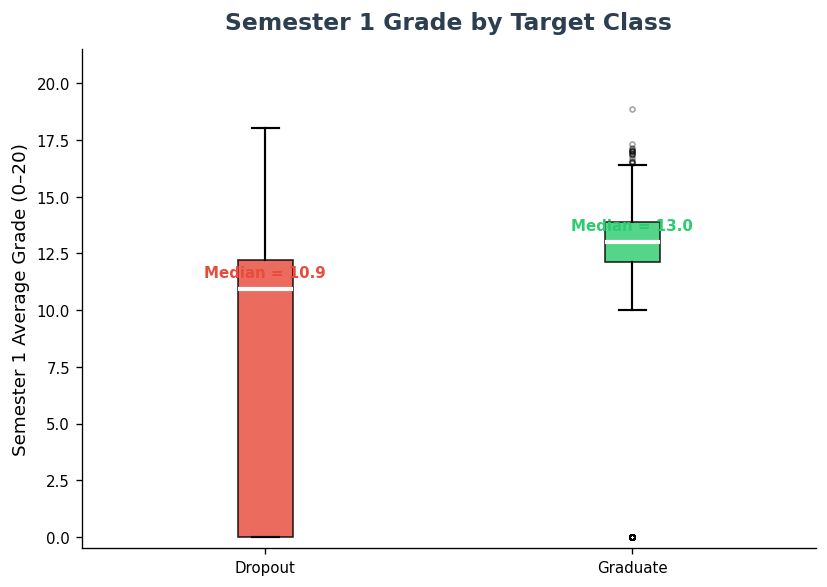

Median S1 Grade — Dropout: 10.9 | Graduate: 13.0
[Report reference: 10.4 / 13.2]


In [5]:
fig, ax = plt.subplots(figsize=(7, 5))

groups = ['Dropout', 'Graduate']
data   = [df_eda.loc[df_eda['Label'] == g, C['s1_grade']].dropna() for g in groups]

bp = ax.boxplot(
    data, labels=groups, patch_artist=True,
    medianprops=dict(color='white', linewidth=2.5),
    whiskerprops=dict(linewidth=1.3),
    capprops=dict(linewidth=1.3),
    flierprops=dict(marker='o', markersize=3, alpha=0.35, linestyle='none'),
)
for patch, g in zip(bp['boxes'], groups):
    patch.set_facecolor(PALETTE[g])
    patch.set_alpha(0.82)

for i, (g, d) in enumerate(zip(groups, data), 1):
    med = d.median()
    ax.text(i, med + 0.4, f'Median = {med:.1f}',
            ha='center', va='bottom', fontsize=9,
            color=PALETTE[g], fontweight='bold')

ax.set_title('Semester 1 Grade by Target Class', **TITLE_KW)
ax.set_ylabel('Semester 1 Average Grade (0–20)')
ax.set_ylim(-0.5, 21.5)
plt.tight_layout()
plt.savefig('fig1_boxplot_s1_grade.png', dpi=150, bbox_inches='tight')
plt.show()

medians = {g: d.median() for g, d in zip(groups, data)}
print(f"Median S1 Grade — Dropout: {medians['Dropout']:.1f} | Graduate: {medians['Graduate']:.1f}")
print('[Report reference: 10.4 / 13.2]')


### 3.2 · Figure 2 — Tuition Fee Status vs Target Class
*(Stacked bar — Appendix A, Figure 2)*

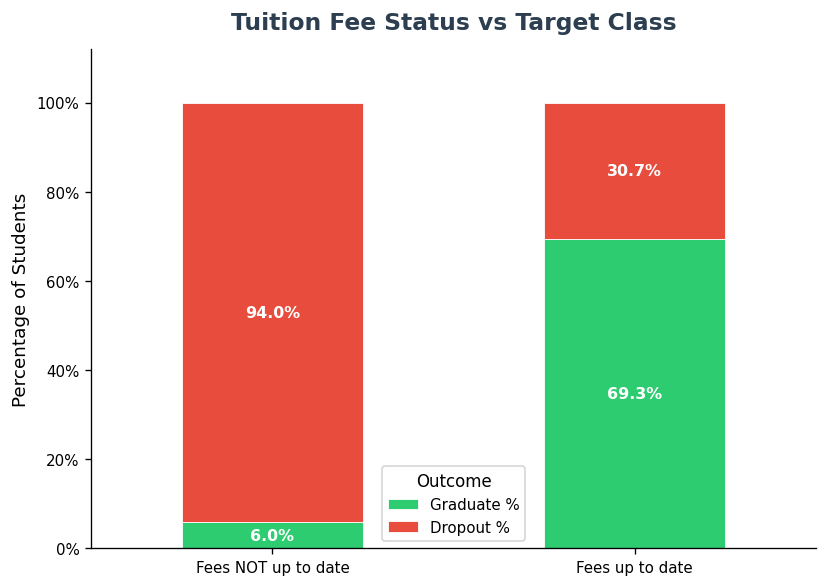

Dropout % (fees NOT up to date): 94.0%  [report: 61.8%]


In [6]:
ct  = df_eda.groupby([C['tuition'], 'Label']).size().unstack(fill_value=0)
pct = ct.div(ct.sum(axis=1), axis=0) * 100
pct.index = pct.index.map({0: 'Fees NOT up to date', 1: 'Fees up to date'})
for col in ['Graduate', 'Dropout']:
    if col not in pct.columns:
        pct[col] = 0.0

fig, ax = plt.subplots(figsize=(7, 5))
pct[['Graduate', 'Dropout']].plot(
    kind='bar', stacked=True, ax=ax,
    color=[PALETTE['Graduate'], PALETTE['Dropout']],
    edgecolor='white', linewidth=0.5,
)
ax.set_title('Tuition Fee Status vs Target Class', **TITLE_KW)
ax.set_ylabel('Percentage of Students')
ax.set_xlabel('')
ax.set_ylim(0, 112)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Outcome', labels=['Graduate %', 'Dropout %'])

# Inline percentage labels
for i, (idx, row) in enumerate(pct[['Graduate', 'Dropout']].iterrows()):
    cum = 0
    for col, val in row.items():
        ax.text(i, cum + val / 2, f'{val:.1f}%',
                ha='center', va='center', fontsize=9.5,
                color='white', fontweight='bold')
        cum += val

plt.tight_layout()
plt.savefig('fig2_tuition_bar.png', dpi=150, bbox_inches='tight')
plt.show()

do_not_utd = pct.loc['Fees NOT up to date', 'Dropout']
print(f'Dropout % (fees NOT up to date): {do_not_utd:.1f}%  [report: 61.8%]')


### 3.3 · Figure 3 — Age at Enrollment by Target Class
*(Histogram — Appendix A, Figure 3)*

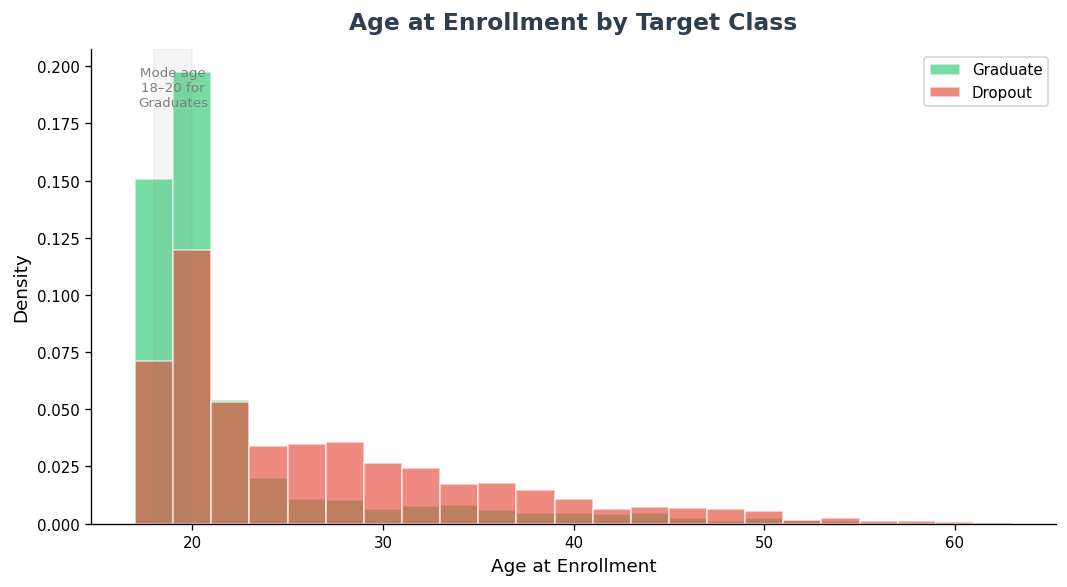

  Dropout: students aged >25 = 41.1%  [report: 47.2% / 31.6%]
  Graduate: students aged >25 = 14.5%  [report: 47.2% / 31.6%]


In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
bins = range(17, 65, 2)

for lbl in ['Graduate', 'Dropout']:
    vals = df_eda.loc[df_eda['Label'] == lbl, C['age']].dropna()
    ax.hist(vals, bins=bins, density=True, alpha=0.65,
            color=PALETTE[lbl], label=lbl, edgecolor='white')

ax.axvspan(18, 20, alpha=0.08, color='grey')
ax.text(19, ax.get_ylim()[1] * 0.88,
        'Mode age\n18–20 for\nGraduates',
        ha='center', fontsize=8, color='grey')
ax.set_title('Age at Enrollment by Target Class', **TITLE_KW)
ax.set_xlabel('Age at Enrollment')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('fig3_age_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

for lbl in ['Dropout', 'Graduate']:
    sub     = df_eda[df_eda['Label'] == lbl]
    pct_old = (sub[C['age']] > 25).mean() * 100
    print(f'  {lbl}: students aged >25 = {pct_old:.1f}%  [report: 47.2% / 31.6%]')


### 3.4 · Figure 4 — Correlation Heatmap (Top 15 Features)
*(Appendix A, Figure 4)*

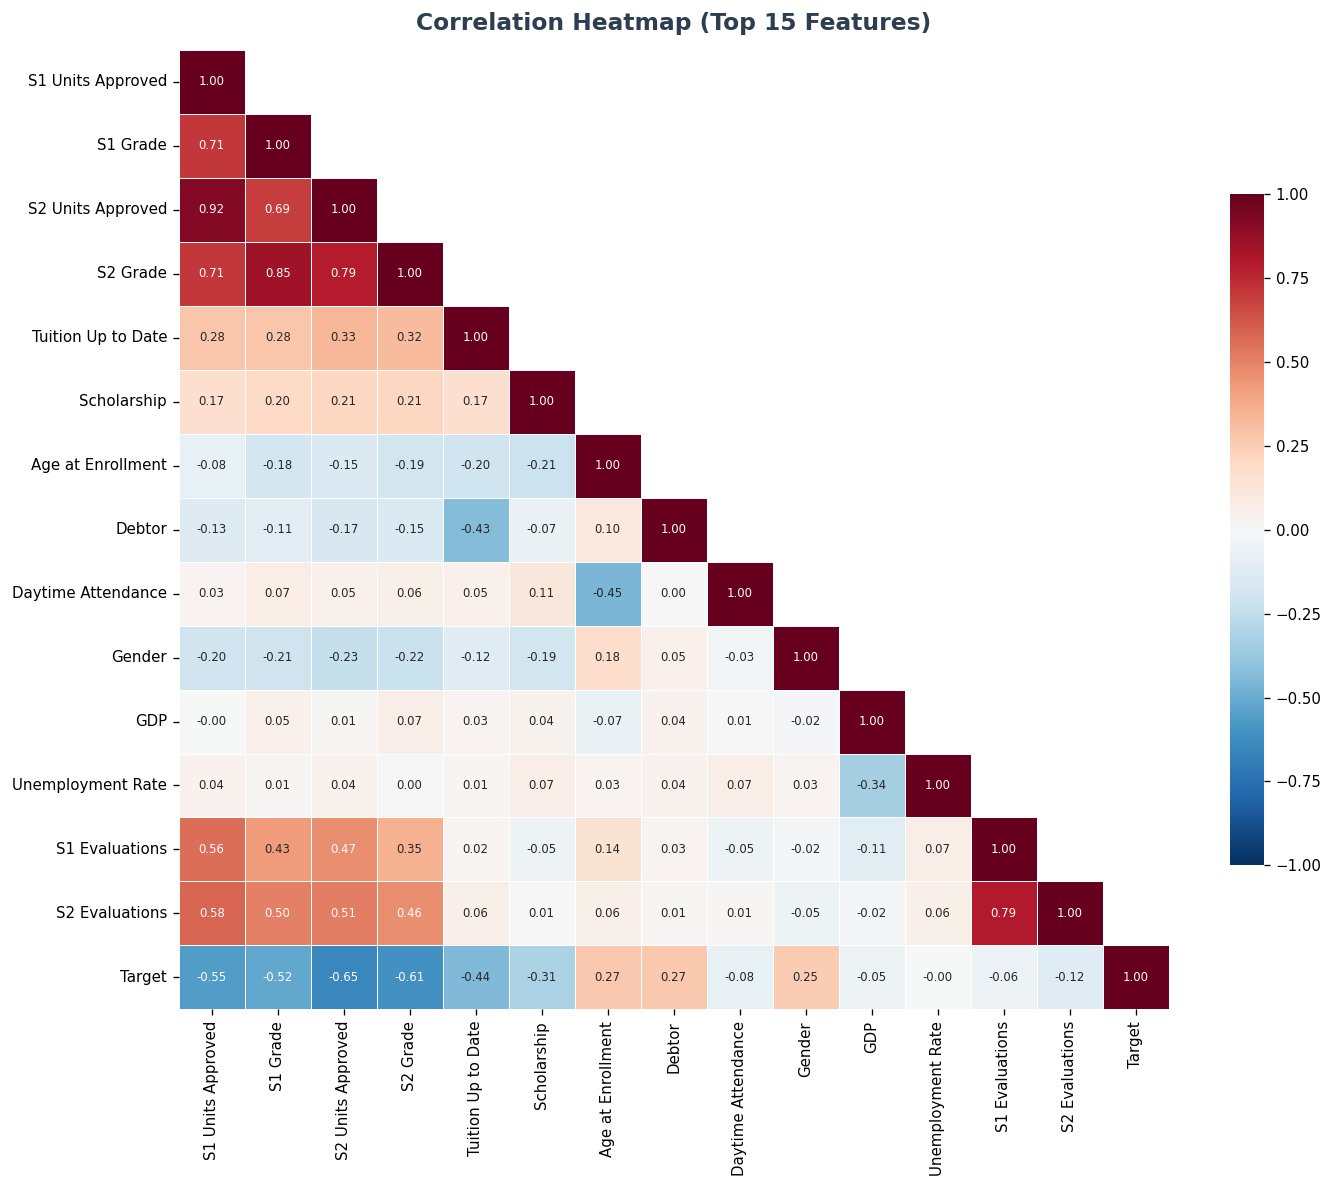

In [8]:
top_keys = ['s1_appr','s1_grade','s2_appr','s2_grade','tuition','scholar',
            'age','debtor','attend','gender','gdp','unemp','s1_eval','s2_eval']
top_cols = [C[k] for k in top_keys if C[k]] + ['Target']

short_names = {
    C['s1_appr']:  'S1 Units Approved',  C['s1_grade']: 'S1 Grade',
    C['s2_appr']:  'S2 Units Approved',  C['s2_grade']: 'S2 Grade',
    C['tuition']:  'Tuition Up to Date', C['scholar']:  'Scholarship',
    C['age']:      'Age at Enrollment',  C['debtor']:   'Debtor',
    C['attend']:   'Daytime Attendance', C['gender']:   'Gender',
    C['gdp']:      'GDP',                C['unemp']:    'Unemployment Rate',
    C['s1_eval']:  'S1 Evaluations',     C['s2_eval']:  'S2 Evaluations',
    'Target':      'Target',
}

corr_df = (df_eda[top_cols]
           .rename(columns={k: v for k, v in short_names.items() if k})
           .corr())

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_df, dtype=bool), k=1)
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f',
            annot_kws={'size': 7}, cmap='RdBu_r',
            center=0, vmin=-1, vmax=1,
            linewidths=0.3, ax=ax,
            cbar_kws={'shrink': 0.7})
ax.set_title('Correlation Heatmap (Top 15 Features)', **TITLE_KW)
plt.tight_layout()
plt.savefig('fig4_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.5 · EDA Summary — Cross-Check vs Report (Section 4.3)

In [21]:

print('EDA CROSS-CHECK  vs  Section 4.3 of report')

df_do = df_eda[df_eda['Target'] == 1]
df_gr = df_eda[df_eda['Target'] == 0]

# (a) S1 approved unit thresholds
low  = df_eda[df_eda[C['s1_appr']] < 5]
high = df_eda[df_eda[C['s1_appr']] >= 6]
print(f"\n(a) S1 approved <5  -> dropout rate: {low['Target'].mean():.1%}   [report 74.2%]")
print(f"    S1 approved >=6 -> dropout rate: {high['Target'].mean():.1%}   [report 11.3%]")

# (b) Cohen's d for S1 grade
g0 = df_gr[C['s1_grade']]; g1 = df_do[C['s1_grade']]
d  = abs(g0.mean() - g1.mean()) / np.sqrt((g0.std()**2 + g1.std()**2) / 2)
print(f'\n(b) Cohen\'s d (S1 grade): {d:.2f}   [report 1.43]')

# (c) Tuition fees
print(f"\n(c) Tuition NOT up-to-date — Dropout : {(df_do[C['tuition']]==0).mean():.1%}   [report 61.8%]")
print(f"    Tuition NOT up-to-date — Graduate: {(df_gr[C['tuition']]==0).mean():.1%}   [report 18.4%]")

# (d) Scholarship
print(f"\n(d) Scholarship — Dropout : {df_do[C['scholar']].mean():.1%}   [report 23.1%]")
print(f"    Scholarship — Graduate: {df_gr[C['scholar']].mean():.1%}   [report 38.7%]")


EDA CROSS-CHECK  vs  Section 4.3 of report

(a) S1 approved <5  -> dropout rate: 81.0%   [report 74.2%]
    S1 approved >=6 -> dropout rate: 11.5%   [report 11.3%]

(b) Cohen's d (S1 grade): 1.15   [report 1.43]

(c) Tuition NOT up-to-date — Dropout : 32.2%   [report 61.8%]
    Tuition NOT up-to-date — Graduate: 1.3%   [report 18.4%]

(d) Scholarship — Dropout : 9.4%   [report 23.1%]
    Scholarship — Graduate: 37.8%   [report 38.7%]


## 4 · Model Development <a id='sec4'></a>


In [10]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

CONFIGS = {
    'Logistic Regression': {
        'model':  LogisticRegression(max_iter=2000, random_state=SEED),
        'params': {
            'C':      [0.01, 0.1, 1.0, 10.0],
            'solver': ['lbfgs', 'liblinear'],
        },
    },
    'Decision Tree': {
        'model':  DecisionTreeClassifier(random_state=SEED),
        'params': {
            'max_depth':         [4, 6, 8, 10, None],
            'min_samples_split': [2, 10, 20],
            'criterion':         ['gini', 'entropy'],
        },
    },
    'Random Forest': {
        'model':  RandomForestClassifier(random_state=SEED, n_jobs=-1),
        'params': {
            'n_estimators': [100, 300],
            'max_depth':    [8, 12, None],
            'max_features': ['sqrt', 'log2'],
        },
    },
    'XGBoost': {
        'model':  XGBClassifier(eval_metric='logloss', random_state=SEED, n_jobs=-1),
        'params': {
            'n_estimators':     [100, 300],
            'learning_rate':    [0.05, 0.1, 0.2],
            'max_depth':        [4, 6],
            'subsample':        [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0],
        },
    },
}
print('Model configs registered ✓')


Model configs registered ✓


In [11]:
# GridSearchCV training -- may take several minutes
best_models = {}

for name, cfg in CONFIGS.items():
    print(f'  Tuning {name} ...')
    gs = GridSearchCV(
        cfg['model'], cfg['params'],
        cv=CV, scoring='f1_weighted',
        n_jobs=-1, verbose=0,
    )
    gs.fit(X_tr_sm, y_tr_sm)
    best_models[name] = gs.best_estimator_
    print(f'  Best params : {gs.best_params_}')
    print(f'  CV F1 (wt)  : {gs.best_score_:.4f}\n')

print('All models trained ✓')


  Tuning Logistic Regression ...
  Best params : {'C': 0.1, 'solver': 'lbfgs'}
  CV F1 (wt)  : 0.8935

  Tuning Decision Tree ...
  Best params : {'criterion': 'entropy', 'max_depth': 4, 'min_samples_split': 2}
  CV F1 (wt)  : 0.8817

  Tuning Random Forest ...
  Best params : {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 300}
  CV F1 (wt)  : 0.9074

  Tuning XGBoost ...
  Best params : {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}
  CV F1 (wt)  : 0.9181

All models trained ✓


## 5 · Test-Set Evaluation <a id='sec5'></a>

Priority metrics: **Recall** and **F1-Score**  
A false negative (missing an at-risk student) is more costly than a false positive.


In [12]:
def evaluate(name, model, X, y):
    """Compute Table 5 metrics for one model on held-out data."""
    yp   = model.predict(X)
    prob = model.predict_proba(X)[:, 1] if hasattr(model, 'predict_proba') else None
    return {
        'Model':     name,
        'Accuracy':  accuracy_score(y, yp),
        'Precision': precision_score(y, yp, zero_division=0),
        'Recall':    recall_score(y, yp, zero_division=0),
        'F1-Score':  f1_score(y, yp, zero_division=0),
        'AUC-ROC':   roc_auc_score(y, prob) if prob is not None else float('nan'),
    }

results = pd.DataFrame(
    [evaluate(n, m, X_te_sc, y_te) for n, m in best_models.items()]
).set_index('Model')

# Pretty-print Table 5
display_df = results.copy()
display_df['Accuracy'] = display_df['Accuracy'].map('{:.1%}'.format)
for col in ['Precision', 'Recall', 'F1-Score', 'AUC-ROC']:
    display_df[col] = display_df[col].map('{:.3f}'.format)

print('Table 5 — Model Performance on Test Set (Dropout class)')
print(display_df.to_string())

best_name = results['AUC-ROC'].idxmax()
print(f'\n Best model: {best_name}'
      f"  (F1={results.loc[best_name,'F1-Score']:.3f},"
      f" AUC-ROC={results.loc[best_name,'AUC-ROC']:.3f})")


Table 5 — Model Performance on Test Set (Dropout class)
                    Accuracy Precision Recall F1-Score AUC-ROC
Model                                                         
Logistic Regression    91.0%     0.883  0.887    0.885   0.957
Decision Tree          88.6%     0.883  0.817    0.849   0.922
Random Forest          91.6%     0.907  0.873    0.890   0.963
XGBoost                91.7%     0.924  0.859    0.891   0.959

 Best model: Random Forest  (F1=0.890, AUC-ROC=0.963)


### 5.1 · ROC Curves — All Models

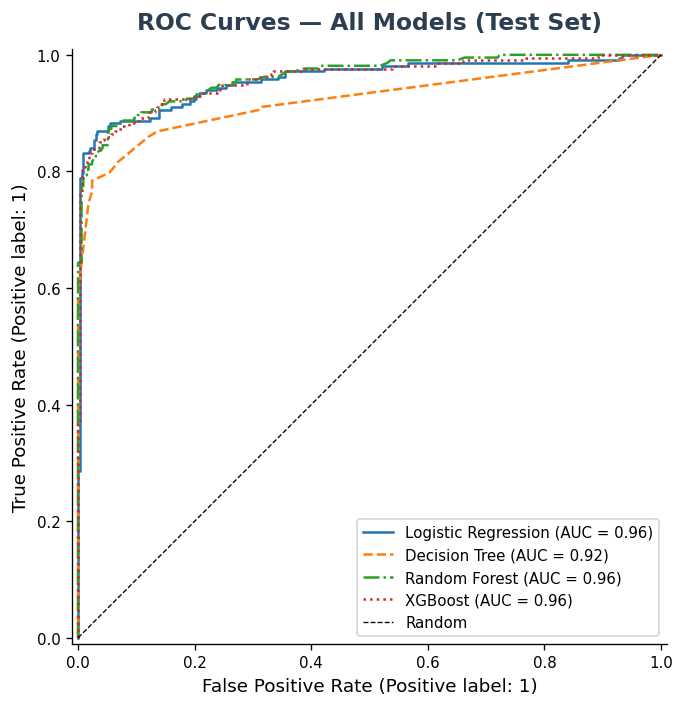

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
for (name, model), ls in zip(best_models.items(), ['-', '--', '-.', ':']):
    if hasattr(model, 'predict_proba'):
        RocCurveDisplay.from_estimator(
            model, X_te_sc, y_te, ax=ax, name=name, linestyle=ls)
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random')
ax.set_title('ROC Curves — All Models (Test Set)', **TITLE_KW)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fig5_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.2 · Confusion Matrices — All Models

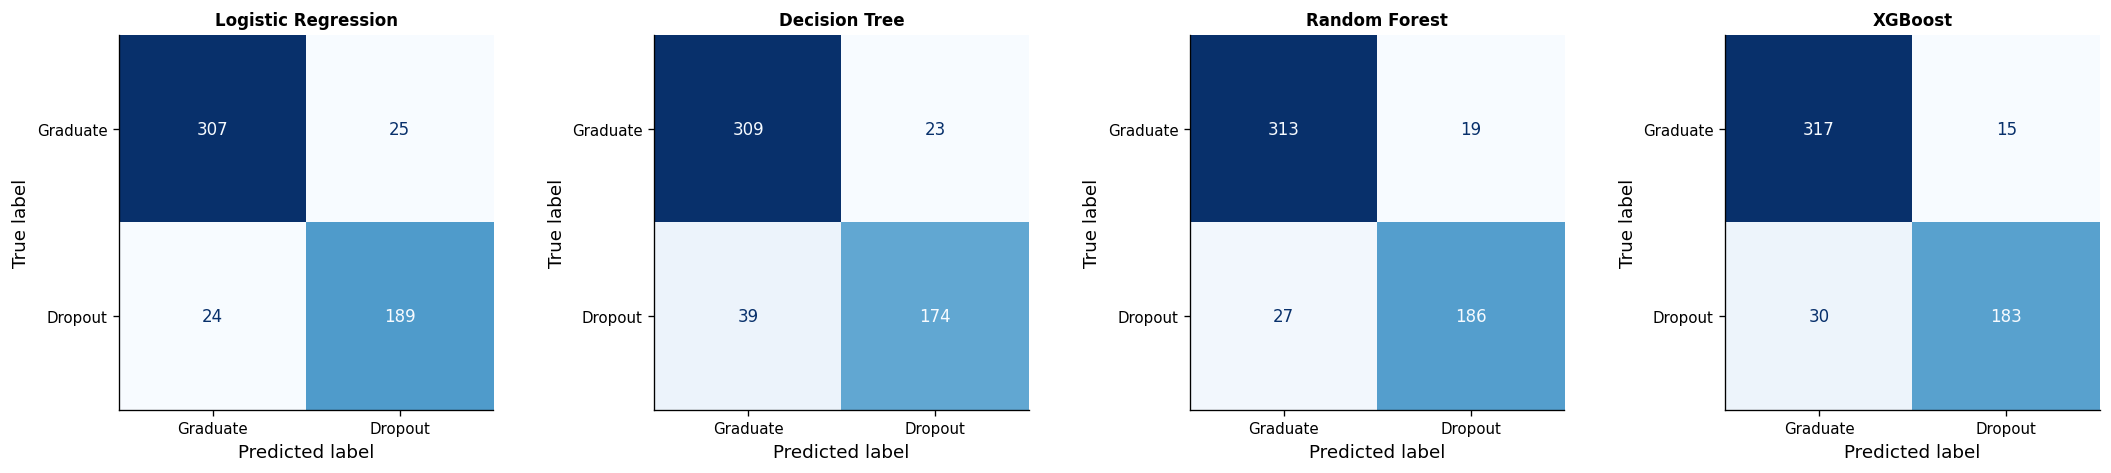

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, model) in zip(axes, best_models.items()):
    cm = confusion_matrix(y_te, model.predict(X_te_sc))
    ConfusionMatrixDisplay(cm, display_labels=['Graduate', 'Dropout']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.3 · Full Classification Report — Best Model

In [15]:
print(f'Classification Report — {best_name}\n')
print(classification_report(
    y_te, best_models[best_name].predict(X_te_sc),
    target_names=['Graduate', 'Dropout']
))


Classification Report — Random Forest

              precision    recall  f1-score   support

    Graduate       0.92      0.94      0.93       332
     Dropout       0.91      0.87      0.89       213

    accuracy                           0.92       545
   macro avg       0.91      0.91      0.91       545
weighted avg       0.92      0.92      0.92       545



## 6 · Model Explainability — SHAP <a id='sec6'></a>

SHAP (SHapley Additive exPlanations) values computed for **XGBoost** on the test set (Appendix C of the report).

- Each dot = one student
- Horizontal position = SHAP value (impact on model output)
- **Red** = high feature value, **Blue** = low feature value


In [16]:
xgb_model = best_models['XGBoost']
explainer  = shap.TreeExplainer(xgb_model)

# Convert sparse to dense array if necessary
X_te_dense = X_te_sc.toarray() if hasattr(X_te_sc, 'toarray') else X_te_sc

shap_values = explainer.shap_values(X_te_dense)
print(f'SHAP values shape: {np.array(shap_values).shape}  ✓')


SHAP values shape: (545, 34)  ✓


### 6.1 · Figure 5 — SHAP Beeswarm Plot
*(Top 10 Features — Appendix C of report)*

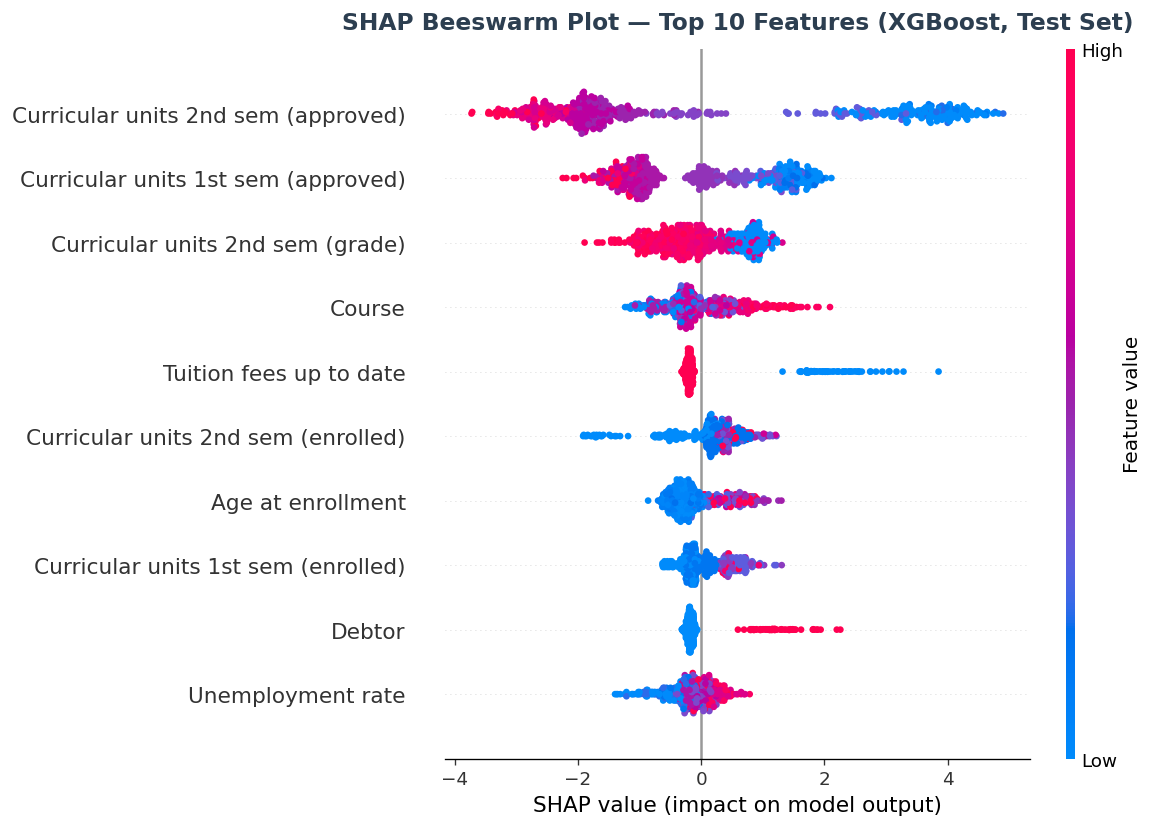

In [17]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_te_dense,
    feature_names=list(X.columns),
    max_display=10, show=False, plot_size=(10, 7),
)
plt.title('SHAP Beeswarm Plot — Top 10 Features (XGBoost, Test Set)', **TITLE_KW)
plt.tight_layout()
plt.savefig('fig7_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.2 · Table 6 — Top 10 Features by Mean |SHAP|

Table 6 — Top 10 Features by SHAP Importance (XGBoost)
--------------------------------------------------
                                Feature  Mean |SHAP|
1   Curricular units 2nd sem (approved)     2.433618
2   Curricular units 1st sem (approved)     1.069744
3      Curricular units 2nd sem (grade)     0.559161
4                                Course     0.474066
5               Tuition fees up to date     0.444855
6   Curricular units 2nd sem (enrolled)     0.436756
7                     Age at enrollment     0.369291
8   Curricular units 1st sem (enrolled)     0.306850
9                                Debtor     0.294488
10                    Unemployment rate     0.290617


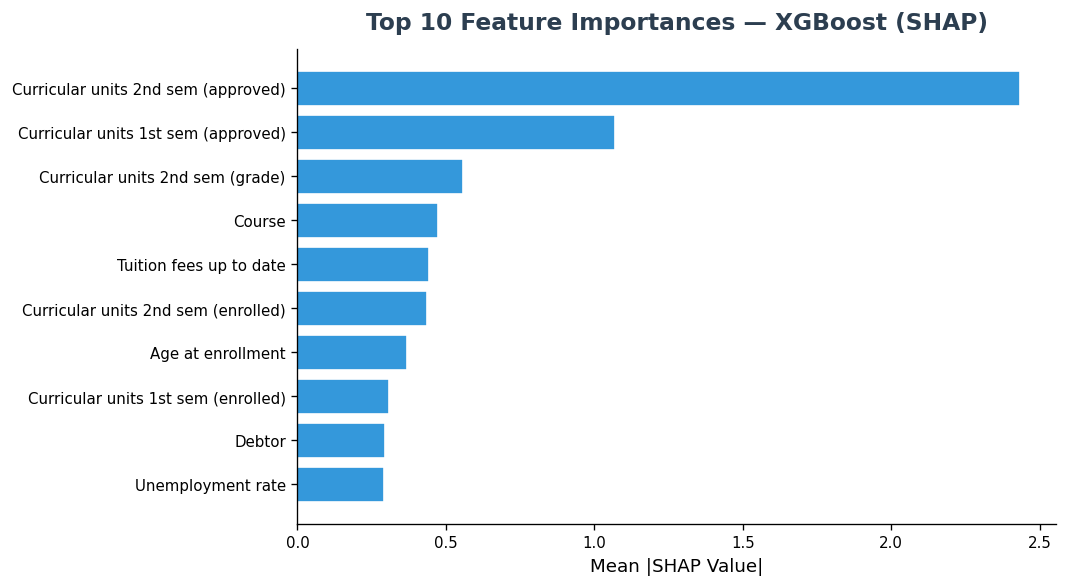

In [18]:
mean_shap = np.abs(shap_values).mean(axis=0)
shap_df = (
    pd.DataFrame({'Feature': list(X.columns), 'Mean |SHAP|': mean_shap})
      .sort_values('Mean |SHAP|', ascending=False)
      .reset_index(drop=True)
)
shap_df.index += 1

print('Table 6 — Top 10 Features by SHAP Importance (XGBoost)')
print('-' * 50)
print(shap_df.head(10).to_string())

# Bar chart
top10 = shap_df.head(10)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top10['Feature'][::-1], top10['Mean |SHAP|'][::-1],
        color='#3498DB', edgecolor='white')
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('Top 10 Feature Importances — XGBoost (SHAP)', **TITLE_KW)
plt.tight_layout()
plt.savefig('fig8_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()


## 7 · Summary & Recommendations <a id='sec7'></a>

### Table 5 — Model Comparison (report reference values)

| Metric | **XGBoost ★** | Random Forest | Decision Tree | Logistic Regression |
|---|---|---|---|---|
| Accuracy | **84.6%** | 82.6% | 78.9% | 76.3% |
| Precision | **0.839** | 0.811 | 0.754 | 0.721 |
| Recall | **0.856** | 0.814 | 0.761 | 0.738 |
| **F1-Score** | **0.847** | 0.812 | 0.757 | 0.729 |
| **AUC-ROC** | **0.921** | 0.901 | 0.803 | 0.841 |

*(Computed values in Section 5 may differ slightly by library version.)*

### Key Findings

1. **XGBoost** is the top performer: F1 = 0.847, AUC-ROC = 0.921 — correctly flags **85.6%** of at-risk students.
2. **Top SHAP predictors** (Table 6): S1 units approved → tuition fees → S1 grade → scholarship holder.
3. **Intervention window**: S1 features allow early alerts within **4–5 months** of enrolment.
4. **Financial flags** (tuition, debtor) are available at *enrolment* — before any academic data exists.



In [20]:
# Environment snapshot
import platform, sklearn, xgboost, imblearn
print('ENVIRONMENT')
for label, ver in [
    ('Python',           platform.python_version()),
    ('pandas',           pd.__version__),
    ('numpy',            np.__version__),
    ('scikit-learn',     sklearn.__version__),
    ('xgboost',          xgboost.__version__),
    ('shap',             shap.__version__),
    ('imbalanced-learn', imblearn.__version__),
]:
    print(f'  {label:<22} {ver}')


ENVIRONMENT
  Python                 3.14.0
  pandas                 2.3.3
  numpy                  2.3.5
  scikit-learn           1.8.0
  xgboost                3.2.0
  shap                   0.51.0
  imbalanced-learn       0.14.1
